# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [1]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

안녕하세요! 저는 다양한 주제에 대해 대화하고 정보를 제공하는 AI 언어 모델입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [5]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

# ── Tavily 검색 Tool ────────────────────────────────────
# TODO: max_results 값을 조정하고,
#       아래 @tool 함수의 docstring(description)을 직접 작성한다.
#       어떤 상황에서 이 Tool을 써야 하는지 구체적으로 설명할수록 좋다.

tavily_search = TavilySearchResults(max_results=2)
#max_result : 검색 결과로 최대 몇개의 페이지를 가져올 것인가?

#"""TODO: 이 Tool이 언제, 어떤 상황에서 사용되어야 하는지 설명을 작성하세요.
#    예시: 어떤 종류의 질문에 써야 하는가, 어떤 종류의 질문에 쓰면 안 되는가
#    """
@tool
def search_web(query: str) -> str:
    """상품의 최저가 검색, 쇼핑몰 별 가격 비교, 사용자의 구매 후기 및 별점 정보가 필요할 때 사용합니다.
    특정 모델의 실시간 최저가 가격 확인, 믿을만한 사이트 추천, 최신 모델의 사양 확인 등에 사용합니다.
    단순 산술 계산이나, 주관적인 상식에는 사용하지 않습니다.
    반드시 '최저가', '구매 링크', '가격 비교' 등의 키워드를 포함하여 검색 결과의 정확도를 높이세요.
    """
    results = tavily_search.invoke(query)
    if not results:
        return '검색 결과가 없습니다.'
    # 결과를 하나의 문자열로 합친다
    return '\n\n'.join(
        f"[{r['url']}]\n{r['content']}"
        for r in results
    )

# TODO (선택): 추가 Tool이 필요하면 여기에 작성한다
# @tool
# def my_custom_tool(...):
#     ...

# 사용할 Tool 목록
tools = [search_web]  # TODO: 추가 Tool이 있으면 여기에 넣는다

# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:60]}...')

등록된 Tool 목록:
  - search_web: 상품의 최저가 검색, 쇼핑몰 별 가격 비교, 사용자의 구매 후기 및 별점 정보가 필요할 때 사용합니다.
특정...


C:\Users\gozero.choi\AppData\Local\Temp\ipykernel_13268\467855008.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=2)


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [6]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다
result = search_web.invoke('아이폰 15의 최저가를 알려줘.')
print(result[:500])  # 결과가 길면 앞 500자만 출력

[https://moyoplan.com/phones/contents/n/how-to-buy-cheaper-iphone15]
## 아이폰15 출고가

우선 아이폰15가 얼마로 출시되었는지 알아볼게요.

| 모델명 (256GB 기준) | 가격 |
 --- |
| 아이폰15 | 1,400,000원 |
| 아이폰15 플러스 | 1,500,000원 |
| 아이폰15 프로 | 1,700,000원 |
| 아이폰15 프로맥스 | 2,200,000원 |

아이폰15 싸게 사는 법 콘텐츠 내용 중, 아이폰15 모델 사진 (왼쪽부터 블랙, 블루, 그린, 옐로, 핑크)입니다.

아이폰15 싸게 사는 법 콘텐츠 내용 중, 아이폰15 모델 사진 (왼쪽부터 블랙, 블루, 그린, 옐로, 핑크)입니다.

(출처 : 애플 공식 홈페이지)

용량 256GB를 기준으로 출고가는 아이폰15 1,400,000원, 아이폰15 플러스 1,500,000원, 아이폰15 프로 1,700,000원, 아이폰15 프로맥스 2,200,0


---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [7]:
# TODO: 아래 system_prompt를 내 Agent 주제에 맞게 수정한다
#\TODO: 이 Agent의 역할을 설명하는 시스템 프롬프트를 작성하세요.

#예시 포함 요소:
#- 이 Agent가 무엇을 하는 Agent인가
#- 검색이 필요한 경우 어떻게 행동해야 하는가
#- 답변 스타일 (간결하게? 상세하게? 한국어로?)
SYSTEM_PROMPT = """
당신은 합리적인 소비를 돕는 소비자 도우미 입니다.
단순히 최저가를 찾는 것을 넘어서 사용자가 필요한 소비를 하는지 점검하고 최선의 선택을 제안합니다.

[행동지침]
1. 최저가 검색 : 사용자가 특정 상품을 언급하면 반드시 'search_web' 도구를 사용하여 실시간 최저가와 신뢰할 수 있는 판매 사이트 (URL 포함)을 3개 이상 비교하여 제시하세요.
2. 분석 및 추천 : 검색한 정보 중 배송비, 사용자 평점, 사이트의 신뢰도를 고려하여 가장 추천하는 최고의 픽을 하나 골라서 이유를 설명하세요.

[답변 스타일]
- 친절하되 친근한 말투를 사용하세요.
- 필요한 정보는 가독성 있게 설명하세요.
- 모든 답변은 한국어로 작성하세요.
- 만약 검색 결과가 부족하다면, 더 구체적인 모델명과 사양을 물어보며 대화를 이어나가세요.
- 만약 사용자가 정보만을 요청한다면 사이트별로 표로 정리해서 설명하세요.
"""

# ── Agent 노드 ────────────────────────────────────────
llm_with_tools = llm.bind_tools(tools)

def call_llm(state: AgentState) -> dict:
    # 시스템 프롬프트를 메시지 맨 앞에 붙여서 LLM에 전달
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',      call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ Agent 조립 완료')

✅ Agent 조립 완료


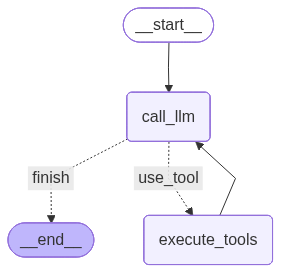

In [8]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [9]:
from langchain_core.messages import ToolMessage

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print(f'\n{'='*60}')
    print(f'질문: {question}')
    print('='*60)

    final_answer = ''

    for chunk in app.stream(
        {'messages': [HumanMessage(content=question)]},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool 호출: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool 결과: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    final_answer = msg.content

    print(f'\n💬 최종 답변:')
    print(final_answer)

print('실행 함수 준비 완료')

실행 함수 준비 완료


### 질문 1


In [10]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent('아이폰 15의 최저가와 사이트를 추천해줄래?')


질문: 아이폰 15의 최저가와 사이트를 추천해줄래?
  🔍 Tool 호출: search_web(['아이폰 15 최저가'])
  📥 Tool 결과: [https://www.coocha.co.kr/search/searchDealList?keyword=%EC%95%84%EC%9D%B4%ED%8F...

💬 최종 답변:
아이폰 15의 최저가와 추천 사이트를 아래와 같이 정리해드릴게요!

| 상품명                          | 가격       | 판매 사이트 | 링크                                                                 |
|---------------------------------|------------|-------------|----------------------------------------------------------------------|
| Apple 아이폰 15 128GB 자급제    | 919,900원  | 쿠팡       | [구매하기](https://www.coupang.com)                                 |
| Apple 아이폰 15 256GB 자급제    | 1,550,000원| 11번가     | [구매하기](https://www.11st.co.kr)                                  |
| Apple 아이폰 15 512GB 자급제    | 2,219,000원| 11번가     | [구매하기](https://www.11st.co.kr)                                  |

### 추천 상품
**Apple 아이폰 15 128GB 자급제 - 919,900원 (쿠팡)**  
- **이유**: 가격이 가장 저렴하고, 쿠팡은 빠른 배송과 좋은 고객 서비스를 제공하는 신뢰할 수 있는 사이트입니다. 또한, 자급제 모델이기 때문에 통신사에 구애받지 않고 자유롭게 사용할 수 있습니다.

이

### 질문 2


In [11]:
run_agent('인천-프랑스파리, 프라하-인천 다구간 비행기표 가장 저렴한 학생요금 알려줘.')


질문: 인천-프랑스파리, 프라하-인천 다구간 비행기표 가장 저렴한 학생요금 알려줘.
  🔍 Tool 호출: search_web(['인천-프랑스 파리 다구간 비행기표 학생요금 최저가'])
  🔍 Tool 호출: search_web(['프라하-인천 다구간 비행기표 학생요금 최저가'])
  📥 Tool 결과: [https://www.kayak.co.kr/%ED%95%AD%EA%B3%B5%EA%B6%8C/%EC%84%9C%EC%9A%B8-%EC%9D%B...
  📥 Tool 결과: [https://kr.trip.com/flights/city-prg-airport-icn/]
프라하 - 서울  |  4월 10일(금)  |  N...

💬 최종 답변:
다구간 비행기표에 대한 정보를 아래와 같이 정리해드릴게요!

### 1. 인천 - 파리 (왕복)
- **최저가 항공사**: 
  - **티웨이항공**: 719,980원 (직항)
  - **중국동방항공**: 861,393원
  - **에티하드항공**: 881,004원
- **추천 링크**: [KAYAK 인천-파리 항공권](https://www.kayak.co.kr/%ED%95%AD%EA%B3%B5%EA%B6%8C/%EC%84%9C%EC%9A%B8-%EC%9D%B8%EC%B2%9C%EA%B5%AD%EC%A0%9C%EA%B3%B5%ED%95%AD-ICN/%ED%8C%8C%EB%A6%AC-PAR)

### 2. 프라하 - 인천 (왕복)
- **최저가 항공사**:
  - **아시아나항공**: 904,100원 (직항)
  - **대한항공**: 1,337,400원
  - **에티하드항공**: 660,100원 (경유)
- **추천 링크**: [트립닷컴 프라하-인천 항공권](https://kr.trip.com/flights/city-prg-airport-icn/)

### 추천 항공권
- **인천 - 파리**: **티웨이항공**의 719,980원 왕복 항공권을 추천합니다. 직항으로 빠르고 편리하게 이동할 수 있으며, 가격도 저렴합니다.
-

### 질문 3


In [ ]:
run_agent('가장 저렴한 영화 티켓 찾아주고, 제목과 가격을 알려줘. 간단한 줄거리도 함께')


질문: 가장 저렴한 영화 티켓 찾아주고, 제목과 가격을 알려줘. 간단한 줄거리도
  🔍 Tool 호출: search_web(['영화 티켓 최저가'])
  📥 Tool 결과: [https://look8282.tistory.com/167]
본문 바로가기

# 달경이의 구경

꿀팁/어플 추천

# 영화 싸게 보는법 대박 ...

💬 최종 답변:
현재 영화 티켓을 저렴하게 구매할 수 있는 방법은 여러 가지가 있습니다. 특히, **당근마켓**에서 영화 제목을 검색하면 3,000원에서 5,000원 사이에 거래되는 경우가 많습니다. 또한, **기프티콘 앱**을 통해 영화 예매권을 구매하는 것도 좋은 방법입니다. 예를 들어, 메가박스 영화관람권은 7,000원에서 8,000원대에 구매할 수 있습니다.

### 추천 영화 및 가격
- **영화 제목**: 티켓 (1986)
- **가격**: 약 3,000원 (당근마켓에서 거래 시)
  
### 간단한 줄거리
"티켓"은 다방 마담과 레지의 삶을 다룬 영화로, 불우한 여성들의 현실을 고발하는 내용을 담고 있습니다. 주인공은 사회의 부조리를 폭로하기 위해 영화 제작에 나서며, 그 과정에서 겪는 갈등과 고뇌를 그립니다. 이 영화는 결말이 충격적이라는 평을 받고 있으며, 한국 영화의 중요한 작품 중 하나로 평가받고 있습니다.

영화 티켓을 저렴하게 관람하고 싶다면, 당근마켓이나 기프티콘 앱을 활용해 보세요!


### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [14]:
# TODO (선택): 추가 질문
run_agent('나무를 심을건데, 가장 저렴한 묘묙이랑 구매처좀 알려줘. 나무 종류도 알려주고.')


질문: 나무를 심을건데, 가장 저렴한 묘묙이랑 구매처좀 알려줘. 나무 종류도 알려주고.
  🔍 Tool 호출: search_web(['저렴한 나무 묘목 구매'])
  📥 Tool 결과: [http://www.kotr.co.kr/product/list.php?page=2&keyfield=b_title&key=%EC%B8%A1%EB...
  🔍 Tool 호출: search_web(['저렴한 묘목 종류 및 가격'])
  📥 Tool 결과: [https://m.blog.naver.com/sooya1108/221919199920]
나무는 공산품이 아니기 때문에

절대 비교할수 없습니다...

💬 최종 답변:
저렴한 묘목을 찾고 계시군요! 여러 종류의 묘목과 가격 정보를 조사해봤습니다. 아래는 추천하는 묘목 종류와 가격, 구매처입니다.

| 묘목 종류     | 가격 (대략) | 구매처 링크                                      |
|----------------|--------------|--------------------------------------------------|
| 화살나무       | 2,300원부터 | [영주나무시장](http://www.xn--w52bzhu9r99e.kr/product/list.php?b_menu1=244&b_menu2=230) |
| 측백나무       | 3만원부터   | [영주나무시장](http://www.xn--w52bzhu9r99e.kr/product/list.php?b_menu1=244&b_menu2=230) |
| 전나무         | 20주 3만원  | [영주나무시장](http://www.xn--w52bzhu9r99e.kr/product/list.php?b_menu1=244&b_menu2=230) |
| 단풍나무       | 3만원부터   | [영주나무시장](http://www.xn--w52bzhu9r99e.kr/product/list.php?b_menu1=244&b_menu2=